# 10. Securing Our API - A

##### 10.01.1.0. Skimming: What did you notice and why? Any Questions

_**What?**_  
Currently the `/newsletters` endpoint accepts a newsletter issue as JSON and then sends emails out to all subscribers.  

_**Why?**_  
Only priviledged uses should be able to publish a newsletter (create a newsletter issue) and send it out to subscribers.  
Right now anyone can hit the endpoint and broadcast whatever they want to our existing mailing list.

_**Questions?**_  
What is the best way to breakdown this chapter because it is quite a bulky one?  

While perusing the bulkiest sections are
- Password-based Authentication
- Login
- Sessions + Seed Users

So a session needs to ensure that we have enough context to clear a section without information overload.

We add a tracing span to record who is calling `POST newsletters`
```Rust
//! src/routes/newsletter.rs
// [...]

#[tracing::instrument(
    name = "Publish newsletter"
    skip(db_pool, email_client, body, request),
    fields(username=tracing::field::Empty, user_id=tracing::field::Empty)
)]
pub async fn publish_newsletter(
    db_pool: web::Data<PgPool>,
    body: web::Json<BodyData>,
    email_client: web::Data<EmailClient>,
    request: HttpRequest,
){
    let credentails = basic_authentication(request.headers()).map_err(PublishError::Auth)?;
    tracing::Span::current().record(
        "username",
        tracing::field::display(&credential.username)
    );
    let user_id = validate_credentials(credentials).await?;
    tracing::Span::current().record(
        "user_id",
        tracing::field::display(&user_id)
    );
    // [...]
}
```

**3. Implement `add_test_user` test helper function.**  
We don't have a complete sign-up flow yet, for now we'll inject a test user directly to the database.
```Rust
//! tests/api/helpers.rs
// [..]

pub async fn spawn_app() -> TestApp {
    // [...]
    let test_app =  TestApp {/**/};
    add_test_user(&test_app.db_pool).await;
    test_app
}

async fn add_test_user(db_pool: &PgPool) {
    let test_user = Uuid::now_v7();
    sqlx::query!(
        r#"
            INSERT INTO users (user_id, username, password)
            VALUES ($1, $2, $3);
        "#,
        test_user ,
        test_user .to_string(),
        test_user .to_string()
    )
    .execute(db_pool)
    .await
    .expect("Failed to create test user.")
}
```

The we add a `test_user` helper method to `TestApp` to retreive the user we just created to replace the our `placeholder` in `post_newsletter` implementation.
```Rust
//! test/api/helpers.rs
// [...]

impl TestApp {

    async fn test_user(&self) -> (String, String) {
        let row  = sqlx::query!(
            r#"SELECT username, password FROM users LIMIT 1;"#,
        )
        .fetch_one(&self.db_pool)
        .await
        .expect("Failed to query test user.");

        (row.username, row.password)
    }

    async fn post_newsletters(&self, body: serde_json::Value) -> reqwest::Response {
        let (username, password) = self.test_user().await;
        reqwest::Client::new()
            .post()
            .basic_auth(username, Some(password))
            .json(&body)
            .send()
            .await
            .expect("Failed to perform newsletter post request in test.")
    }
}
```

### 10.02.3. Password Storage (bulky)

##### 10.02.3.0.1. Deep Dive: Summarize, ELI5, Connect

_**Summary**_  
This section is one of the more bulkier sub-sections of the current chapter. We can break it down into
1. Storing cryptographic hashes of a password instead of the raw passwords. We explore `SHA256` algorithm for effecient hashing of password strings
2. We unpack drawbacks and different flaws that attackers use to crack hashed passwords
3. We default to `argon2id` based password hashing + salting to store password string more securly and more computationally demanding to crack

This way we implement first the straightforward way we could store cryptographic passwords, then aftern analyzing the potential issues we  
implement the OWASP recommended way of cryptographically storing passwords.

#### 10.02.3.1. No Need To Store Raw Passwords

##### 10.02.3.1.0. Skimming: What did you notice and why? Any Questions

_**What?**_    
_Injective_
> Meaning for every unique input a function produces a unique output.  
> IF two outputs are the same, their original inputs must have been identical as well.
>
> **Example**  
> $f(x) = 2x + 1$ is an injective function because we get a unique output for every unique input  
> $f(x) = x^2$ is not an injective function because $x$ could be positive or negative and yeild the same output. e.g. 
> $-2$ or $2$

_**Wny?**_  
A password transformation password has to be injective such that if we store the tranformation on the database we can still verify against the  
actually password. i.e. $x \ne y$ then $f(x) \ne f(y)$ 

_**Questions?**_  
None.

##### 10.02.3.1.1. Deep Dive: Summarize, ELI5, Connect

_**Summary**_  
Right now we are validating the user credentials using the raw password stored in the database. If an attacker compromised the database, they would have  
access to all the passwords and can easily start impersonating users. They would also not be limited to our service, but other services where a user used the same  
password.

Because we are only checking for equality of passwords we can transform the raw password provided by a user and store that instead. Then use the transformed password  
for our equality check. The tranformation of the password has to meet the following criteria
1. The tranformation function on the raw password input has to be injective. This means for every unique input we have a unique output aka no two tranformation would produce the
   same output.
2. It should be impossible to do an inverse transformion. Once we produce an output it should be impossible to tell how the input can be derived, or how the output was produced.
   i.e. if an example transformation produced _"elloh"_ from _"hello"_ we can easily tell that our transform function reverses an input.
2. The input should completely uncorrelated to the output. In that a little change in the input, produces a completely different output that seems almost completely random  
   a.k.a. **avalanche effect**.

So what we need is a _**cryptographic hash function**_. 
- _cryptographic_ satisfies the uniformatiy property we discussed in the third criterion above. If the input string changes even a little the output is completely different and
  uncorrelated with the initial unchanged input string (_avalanche effect_)
- _hashing_ where we take a string from the input space and map it to a **fixed length** output. We differentiates hashing from encoding or encryption.
    - encoding means we can decode
    - encrypt means we can decrypt. 

    We cannot reverse a hash. Once one is generated we cannot get back to the original input string. This satisfies our second criteria.

What about _injectivity_?  
Hashing functions cannot be 100% injective. There is a high likelyhood though that if $f(x) == f(y)$ then $x==y$ even though not 100%. This is due to the possibility of collisions.  
Using a larger output space ($\ge$ 256 bits) makes collisions less likely. But again to completely down to 0%.

It is theoretically possible to create a perfect hashing algorith if the input length is fixed i.e. password length is capped

#### 10.02.3.2. Using A Cryptographic Hash

##### 10.02.3.2.0. Skimming: What did you notice and why? Any Questions

_**What?**_  
`format!("{:x}", password_hash)` to get hex-string.  
We add a `TestUser` to generate, store and access a test user that we use with `TestApp` in `spawn_app`


_**Why?**_  
That means to print something in hex we'd run `println!("{val:x}")`.   
Nice clean pattern to generate a test user with a cryptographically hashed password.

_**Questions?**_  
What about binary?  
As I suspected `println!("{val:b}")`

##### 10.02.3.2.1. Deep Dive: Summarize, ELI5, Connect

_**Summary**_  
Here we use SHA3-256 as our cryptographic hashing algorithm to hash our password for starters. We shall discuss the drawbacks for using it later.  
For now here's a great video on the Secure Hash Algorithm [SHA256](https://www.youtube.com/watch?v=orIgy2MjqrA&list=PLqppJXROAZOUr_3xmAk6LTSGdmE3dM3-c)

The main point is that we need to store password hashes instead of raw password and the sha3-256 algorithm provides a good starting point.

_**Deep Dive: ELI5**_

So how are we going to do this pratically?
1. We add the `sha3` crate
2. We add a migration to rename the `password` column to `password_hash` since we are no longer storing raw password text but a hash.
3. We update `validate_credentials` to query matching `password_hash` which means using `sha3` crate to generate a hash of our original password.
   As we do this we convert the `bytes` returned by `sha3` to a hex string that we can query with. Because `sha3` returns an array of bytes instead of a
   string/text.
4. We update our test helpers to store and retrieve a test user with a `password_hash` instead of a raw password.
   - Add a `TestUser` struct and implement a `generate` constructor and `store` method
   - Add a `test_user` field to `TestApp` and make the appropriate `generate` and `store` calls
   - Update `post_newsletter` to use `TestApp`'s `test_user`

Alright let's get to it.

**1. Add the `sha3` crate**
```bash
cargo add sha3
```

**2. Add rename password column migration**  
Because we want to store a `password_hash` instead of raw `password` text we rename the `users` table column to reflect this
```bash
sqlx migrate add rename_password_column
```

And the in the `.sql` script file
```SQL
ALTER TABLE users RENAME COLUMN password TO password_hash;
```

We can then run the migration with
```bash
sqlx migrate run
```

Our project stops compiling, with the error below

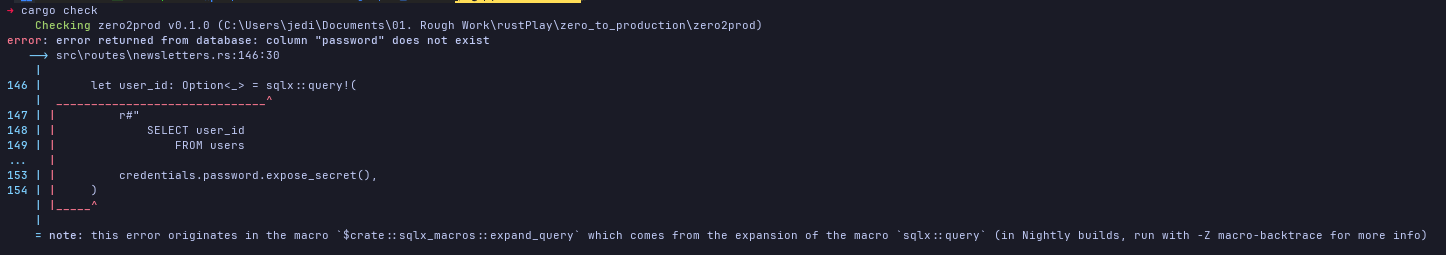

**3. Update `validate_credentials`**  
This should break our implementation because we were originally using `SELECT` on a `password` column.  
Also we the raw `credentials.password` wont work. We need to hash the extracted credentials to perform the query.  
Lets update accordingly.
```Rust
//! src/routes/newsletter.rs
// [...]

async fn validate_credentails(/**/) -> Result<Uuid, PublishError> {
   let password_hash = sha3::Sha3_256::digest(
       credentials.password.expose_secret().as_bytes()
   );
    
    // let password_hash = format!("{:x}", password_hash);
    let password_hash = hex::encode(password_hash);

    let user_id = sqlx::query!(
        r#"
            SELECT user_id
                FROM users
            WHERE username = $1 AND password_hash = $2;
        "#,
        credentials.username,
        password_hash,
    )
    .fetch_optional(db_pool)
    .await
    .context("Failed to perform query to validate auth credentials")
    .map_err(Publish::Unexpected)?;
    // [...]
}
```

A big difference between our implementation and the original is the use of the `hex` crate instead of `format!("{:x}", password_hash)` for getting a hex string from  
our password hash.

Without the conversion of the password_hash into a hex string we would get the error below, which in short tells us that a raw password hash returns a Array of `u8`s  
instead of `&str`.

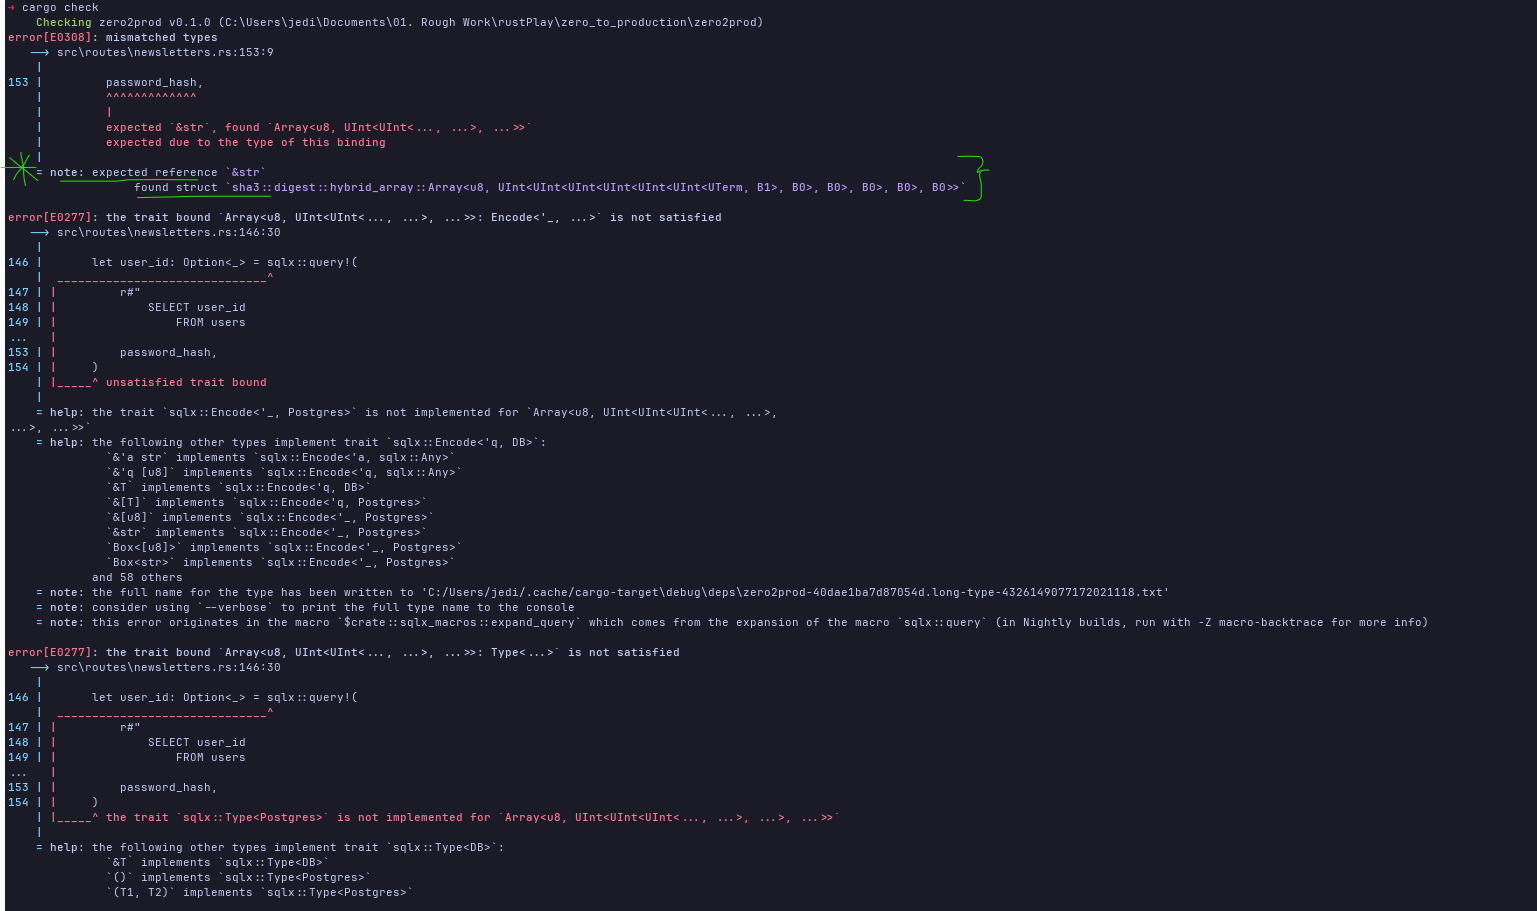

**4. Update test helper to use `password_hash` as opposed to raw `password`**  

We currently now have the errors below in a our tests

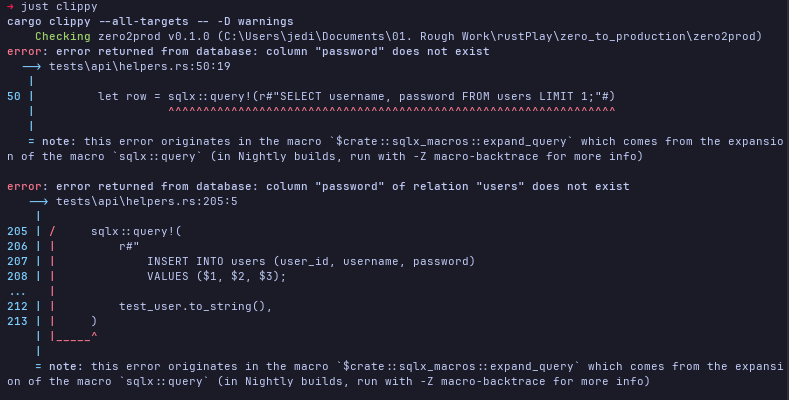

This means we have to update how we are storing our initial `test_user`. We create a `TestUser` struct that we'll use to work  
with `test_user` credentials
<span id="sha3"></span>
```Rust
//! tests/api/newsletter.rs
// [...]

pub struct TestApp {
    // [...]
    pub test_user: TestUser
}

impl TestApp {
    pub async post_newsletter(/**/) -> reqwest::Response {
        reqwest::Client::new()
            .post()
            .basic_auth(&self.test_user.username, Some(&self.test_user.password_hash))
    }
}

pub async spawn_app() {
    // [...]
    let test_app = TestApp {
        // [...]
        test_user: TestUser::generate(),
    };
    test_app.test_user.store(&test_app.db_pool).await;
    test_app
}

struct TestUser {
    user_id: Uuid,
    username: String,
    password_hash: String,
}

impl TestUser {
    fn generate() -> TestUser {
        let user_id = Uuid::now_v7();
        TestUser {
            user_id,
            username: user_id.to_string(),
            password: user_id.to_string(),
        }
    }

    async fn store(&self, db_pool: PgPool) {
        let password_hash = sha3::Sha3_256::digest(
            self.password.as_bytes()
        );
        let password_hash = format!("{:x}" password_hash);
        sqlx::query!(
            r#"
                INSERT INTO users (user_id, username, password_hash)
                VALUES ($1, $2, $3);
            "#,
            self.user_id,
            self.username,
            password_hash
        )
        .execute(db_pool)
        .await
        .expect("Failed to perform insert test user query.");
    }
}
```

#### 10.02.3.3. Preimage Attack

##### 10.02.3.3.0. Skimming: What did you notice and why? Any Questions

_**What?**_  
Exponential time complexity ($2^n$) for a brute force attach to match an input string with SHA 256 hash of the password we are trying to hack.  
Where $n$ is the hash length in bits.  
Where $n > 128$ a preimage attack is unfeasible

_**Why?**_  
The name _Preimage attack_. 

_**Questions?**_  
None


##### 10.02.3.3.1. Deep Dive: Summarize, ELI5, Connect

_**Summary**_  
Does our current hashing mechanism using `sha3` make our password secure? 

We explore a couple of common attacks
1. Preimage attacks
2. Naive dictionary attacks
3. Dictionary attacks using rainbow tables for example.

Here we start with Preimage attacks.

What is a _preimage_ attack?  
Starting from the basic definition of a preimage, we are basically trying to reverse engineer the original password given a hash.  
We conclude that for a hash where its fixed length output is greatar than 128 bits it is commputationally unfeasible using brute force  
because the time complexity is $2^n$ where n in this case is $> 128$ which means $2^{(> 128)}$ 

In our case we are using SHA3-256 making our password has preimage resilient.

Great breakdown from ChatGPT differentiating between [preimage attacks from second preimage and collisions reslience](https://chatgpt.com/share/6a3b8d15-f6ac-83ea-9caa-f9f44fcbf3fc)

#### 10.02.3.4. Naive Dictionary Attack.

##### 10.02.3.4.0. Skimming: What did you notice and why? Any Questions

_**What?**_  
The math to estimate how long it would take to brute force an alphanumeric password shorter than 17 characters.  
Introduced to the concept of _rainbow tables_. Cool [video](https://www.youtube.com/watch?v=OzVzo9gtiec) and [wiki](https://en.wikipedia.org/wiki/Rainbow_table)

_**Why?**_  
Heard about rainbow tables alot when it comes to securing passwords

_**Questions?**_  
None


##### 10.02.3.4.1. Deep Dive: Summarize, ELI5, Connect

_**Summary**_  
What about when we reduce the search space by making some assumptions about the input password, such as length and exclude symbols?  
Here I think the book means naive brute force dictionary attack where we use a 17 character alphanumeric password and walks through the math.  
The summary is though that if the input space is reduced enough advance GPU can allow brute force speed ups where we are able to generate billions  
of hashes for different alphanumeric character combinations.

The book gives an example of how researchers managed to compute ~900 million SHA-512 hashes per second using GPU.

However a brute force attack is easy to frustrate by including something as simple as capitalized alphabets in the alphanumeric set.

Really great [video](https://www.youtube.com/watch?v=7U-RbOKanYs&t=715s) on password cracking via native dictionary brute force and sophisticated dictionary attacks

#### 10.02.3.5. Dictionary Attack

##### 10.02.3.5.0. Skimming: What did you notice and why? Any Questions

_**What?**_  
Cryptographic algorithms we discussed until now are designed to be fast. Meaning it is possible to conpute the inverse transform on consumer hardware

_**Why?**_  
Having a cryptographic algorithm that computes hashes fast/effectively is actually a flaw. We need to make the hashes hard/slow to compute inorder to make it
even more difficult for attackers who may have access to dictionaries of hashes who may use rainbow tables.

_**Questions?**_  
None

##### 10.02.3.5.1. Deep Dive: Summarize, ELI5, Connect

_**Summary**_  
A non-naive dictionary attack takes advantage of widely available password and hash combinations dictionaries of known password leaks. Here an attacker  
takes advantage of these dictionaries + compute to be able to crack password hashes to get original password.

The key insight here is that SHA3 hash functions are computationally efficient allowing us compute hashes very fast and this is only made better with dictionaries.  

We need something much **slower** that makes it computationally expensive to generate hashes. Such that even when someone has the hashes it is computationally unfeasible  
to hash a dictionary of password that generate the hashes the were compromised.

#### 10.02.3.6. Argon2

##### 10.02.3.6.0. Skimming: What did you notice and why? Any Questions

_**What?**_  
- Open Web Application Security Project ([OWASP](https://cheatsheetseries.owasp.org/index.html))
- `password_hash` crate

_**Why?**_  
Should be good to revisit and explore the material. We start with the [Password Storage Cheat Sheet](https://cheatsheetseries.owasp.org/cheatsheets/Password_Storage_Cheat_Sheet.html)  when looking at  
Argon2. Other cheatsheets also looking quite information rich.

Seems  like we replace what we were doing before with `sha3::SHA_256::digest` with 2 crates, `argon2` and `password_hash`, and we need to include a salt inorder to  
appropriately hash out password.

_**Questions?**_  

None

##### 10.02.3.6.1. Deep Dive: Summarize, ELI5, Connect

_**Summary**_  

We take a look at OWASP's summary recommendation when it comes to password storage

<div style="background-color: #313B51; color: white; padding: 15px; border-radius: 15px;">

- Use [Argo2id](https://cheatsheetseries.owasp.org/cheatsheets/Password_Storage_Cheat_Sheet.html#argon2id) with a minimum configuration of 19MiB of memory
  an iteration count of 2, and 1 degree of parallelism.
- If [Argon2id](https://cheatsheetseries.owasp.org/cheatsheets/Password_Storage_Cheat_Sheet.html#argon2id) is not available use
  [scrypt](https://cheatsheetseries.owasp.org/cheatsheets/Password_Storage_Cheat_Sheet.html#scrypt) with a minimum CPU/memory cost parameter of $2^17$,
  a minimum block size of 8(1024 bytes), and a parallelization of 1.
- For legacy system using [bcrypt](https://cheatsheetseries.owasp.org/cheatsheets/Password_Storage_Cheat_Sheet.html#bcrypt), use a work factor of 10 or
  more and with a password limit of 72 bytes
- If FIPS-140 compliance is required, use [PBKDF2](https://cheatsheetseries.owasp.org/cheatsheets/Password_Storage_Cheat_Sheet.html#pbkdf2) with a work
  factor of 600,000 or more and set with an internal hash function of HMAC-SHA-256.
- Consider using a [pepper](https://cheatsheetseries.owasp.org/cheatsheets/Password_Storage_Cheat_Sheet.html#peppering) to provide additional defense
  in depth(though alone, it provides no additional secure characteristics) 
  
</div>

This is an updated excerpt from the [OWASP Password Storage Cheat Sheet](https://cheatsheetseries.owasp.org/cheatsheets/Password_Storage_Cheat_Sheet.html#argon2id).
Make sure to check the differences from the original excerpt added in the Zero To Production book.

Really good summative [video](https://www.youtube.com/watch?v=qQAhprPM5lw) resource on why argon2.

We then go about adding Argon2id to replace the password hashing we did with `sha3`. To do this we;
1. Add the `argon2` crate and instantiate our argon `hasher` with the requisite configs.
2. Add a `salt` column to our `users` table to make our password hashes even more robust.
3. Update our sqlx query to return `user_id`, `expected_password_hash` and `salt` so that we can hash our extracted `credential.password` together with the store `salt`
   before doing an equality check with our `expected_password_hash`
4. We then remove our initial hasher and prefer to use argon's `PasswordHash::new` to return a **PHC** string formated `expected_password_hash` that we use to verify
   our passed in credentials with `Argon2::default().verify_password`
5. We than add a migration to `drop_salt_column_from_users`.
6. Finally we update our `TestUser`'s `store` method to store an argon2id `password_hash`

Notice that we add a `salt` column to illustrate its usefulnes and then remove it because argon handles it for us.  
Also notice the the above tasks cover the next few sections.

Alright. lets get into it

**1. Add the `argon2` dependency and initialize our argon `hasher` with requisite configs**.  
```bash
cargo add argon2 --feature std
```

Then in we update `src/routes/newsletter.rs` as follows, following the OWASP guidelines on the recommended configuration.
```Rust
// src/routes/newsletter.rs
// [...]
use argon2::{Algorithm, Argon2, Version, Params};

// [...]

async fn validate_credentials(/**/) -> Result<Uuid, PublishError> {
    let hasher = Argon2::new(
        Algorithm::Argon2id,
        Version::0x13,
        Params::new(19_000, 2, 1, None)
            .context("Failed to build Argon2 params")
            .map_err(PublishErr::Unexpected)?
    );

    // [...]
}
```

`Argon2` implements a `PasswordHasher` trait (a re-export from the `password-hash` crate) that requires an additional `salt` parameter.
```Rust
//! password_hash/traits.rs

pub trait PasswordHaser {
    // [...]
    fn hash_password<'a, S>(
        &self,
        passwrod: &[u8],
        salt: &'a S
    ) -> Result<PasswordHash<'a>>
    where 
        S: AsRef<str> + ?Sized;
}
```

#### 10.02.3.7. Salting

##### 10.02.3.7.0. Skimming: What did you notice and why? Any Questions

_**What?**_
We re-order `validate_credentials`, querying the `user_id`, `password_hash` (_expected_password_) and `salt` first before hashing the password  
got from the request to do a comparison against.

_**Why?**_
Was wondering where we insert a hashed & salted password, and realized that in the handler we are only evaluating the credentials that come with the  
`publish_newsletter` requests are valid.

_**Question?**_  
None

##### 10.02.3.7.1. Deep Dive: Summarize, ELI5, Connect.

_**Summary**_  
_What is salting and why do we need it?_  
Imagine a compromised user database where an attacker is able to access user password hashes. Our sophisticated attacker uses dictionaries and rainbow tables and  
is able to get a number of raw password strings from the hashes. What can we do to safe gaurd users if there passwords were compromised?

This is where salting helps us.  
A salt is a random string that we can append to a user password that allows us to generate a completely new hash. Each user gets their own salt, ensuring that even if
2 users had identical password, once we append our salt, there resulting hashes will be completely different.

If our application was compromised, all we have to do is generate new salts, while maintaining the same passwords. If the user used the same password on other applications  
and they also apply a salt, comprised password hashes are no longer of any usefulness to an attacker.

Adding a salt makes it computationally unfeasible to rehash compromised passwords.

We'll start by adding a `salt` column to our `users` table.  
What if an attacker is able to get a hold of the password_hashes + salts?
Well, they have to compute $dictionary\_size \times n\_user$ hashes instead of just the $dictionary\_size$. Furthermore pre-computing the hashes is no longer an option  
<span>&mdash;</span> this buys us time to detect the breack and take action (e.g. force a password reset for all users)

**2. Add a `salt` column to our `users` table to make our password hashes even more robust.**  

Let's add a `salt` column to our users table.
```bash
sqlx migrate add add_salt_to_users
```
```SQL
ALTER TABLE users ADD COLUMN salt TEXT NOT NULL UNIQUE;
```

Then we update `validate_credentials` query by retreving `user_id`, `password_hash` and `salt`.  
We'll need the `salt` when hashing the extracted credentials password from the request. Then we'll do an equality check with the queried password.
```Rust
//! src/routes/newsletter.rs
// [...]
use argon2::{
    Algorithm, Argon2id, PasswordHasher, Params, Version,
    password_hasher::SaltString
};

//[...]

async fn validate_credentials(/**/) -> Result<Uuid, PublishError> {
    let row: Option<_> = sqlx::query!(
        r#"
            SELECT user_id, password_hash, salt
                FROM users
            WHERE username = $1
        "#,
        credentials.username,
    )
    .fetch_optional(&db_pool)
    .await
    .context("Failed to perform a query to retrieve stored credentials.")
    .map_err(PublishError::Unexpectd)?;

    let (user_id, expected_password_hash, salt) = match row {
        Some(row) => (row.user_id, row.expected_password_hash, row.salt)
        None => return Err(PublishError::Auth(anyhow::anyhow!("Invalid Username")));
    }

    let hasher = Argon2::new(
        Algorithm::Argon2id,
        Verson::0x13,
        Params(19_000, 2, 1, None)
            .context("Failed to build argon2 params.")
            .map_err(PublishError::Unexpected)?
    );

    // NEW: We need to build a string salt from 
    let salt = SaltString::encode_b64(salt.as_bytes())
        .context("Failed to base-64 encode salt")
        .map_err(PublishError::Unexpected)?;

    let password_hash = hasher.hash_password(
        credentials.password.expose_secret().as_bytes(),
        &salt
    )
    .context("Failed to hash password.")
    .map_err(PublishError::Unexpected)?;

    let password_hash = hex::encode(password_hash.hash.unwrap());

    if expected_password_hash != password_hash {
        Err(PublishError::Auth(anyhow::anyhow!("Invalid password")))
    } else {
        Ok(user_id)
    }
}
```

**Note:** That we've had to encode the retreived `salt` using `SaltString::encode_b64` to return a `SaltString` that we can use when calling `.hash_password`. The original implementation  
did not require this.

In our case our code compiles and we do not get a `the trait LowerHex is not implemented error.` This is because we are using `hex::encode` on the resulting `password_hash.hash.unwrap()`. 

However we will still be missing out on the advantages that are offered by using a PHC String Format.


#### 10.02.3.8. PHC String Format

##### 10.02.3.8.0. Skimming: What did you notice and why? Any Questions

_**What?**_
- **PHC** _string_ - Password Hashing Competition String.
- We remove the _salt_ column that we added in the previous section.

_**Why?**_
- Interesting to know the PHC string format is the result of winning a competition on secure password hashing and storage.
- Argon2 takes care of adding a random salt, via the `PasswordHash::new` that returns to us a valid PHC string format password hash.

_**Question?**_  
None


##### 10.02.3.8.1. Deep Dive: Summary, ELI5, Connect.

_**Summary**_  

_What is the PHC String format and why do we need/use it?_  
PHC stands for $\textsf{Password Hasing Competition}$, and the string format allows us to encode, the hashing algorithm used to generate the hash, the version &  
core params, the salt and the password_hash itself.

Why do we need it?   
Newer and better hashing algorithms can arise, are existing algorithms upgraded to higher versions, or params might need tweaking as hardware improvments happen.
> For example in the book we originally start with a `m_cost` of 15MiB. As of today as per the OWASP cheatsheet the `m_cost` is now 19MiB.

To account for the updates, and changes that may occur in password hashing we need a way to maintain stable backward compatibility while still making upgrades simple.
Take a scenario where older users of our platform use a different hashing algorighm version compared to new users when an application upgrades.  
PHC provides a reliable way to maintain hashed passwords while allowing us flexibility to upgrade, because a password hash's meta data is enconded in the string itself,
so any authentication routine will know how to hash and verify passwords, allowing for seemless migration.

An example of a PHC string looks like this:
```bash
#${algorithm}${algorithm version}${comma separated algorithm params}${hash}${salt}
$argon2id$v=19$m=65536,t=2,p=1$gZiV/M1gPc22ElAH/Jh1Hw$CWOrkoo7oJBQ/iyh7uJ0LO2aLEfrHwTWllSAxT0zRno
```

Alright onto the how.
`argon2` crate exposes `PasswordHash` which is Rust's implementation of the PHC string format. For verification we can rely on `PasswordVerifier` trait exposed by `argon2` as  
well. By passing the expected password via `PasswordHash`, `Argon2` can infer the what load paramereters and salt were used to verify if the password candidate is a match.

We update `validate_credentials` as follows;
```Rust
//! src/routes/newsletter.rs
// [...]
use argon2::{Argon2, PasswordHash, PasswordVerifier};

async fn validate_credentials(/**/) -> Result<Uuid, PublishError> {
    let row: Option<_> = sqlx::query!(
        r#"
            SELECT user_id, password_hash
                FROM users
            WHERE username = $1
        "#,
        credentials.username,
    )
    .fetch_optional(db_pool)
    .await
    .context("Failed to perfom query to retrieve stored credentials.")
    .map_err(PublishError::Unexpected)?;

    let (user_id, expected_password) = match row {
        Some(row) => (row.user_id, row.expected_password),
        None => return Err(PublishError::Auth(anyhow::anyhow!("Invalid Username.")))
    };
    
    let expected_password_phc_format = PasswordHash::new(&expected_password)
        .context("Failed to parse hash in PHC String format.")
        .map_err(PublishError::Unexpected)?;
    
    Argon2::default()
        .verify_password(
            credentials.password.expose_secret().as_bytes(),
            &expected_password_phc_format
        )
        .context("Invalid Password.")
        .map_err(PublishError::Auth)?;

    Ok(user_id)
}
```

This means that we don't need to store and query the `salt` separately to create the hash since it is already part of the PHC string format. As we'll see later, we'll add the  
`salt` before generating the `password_hash` for storage. This means that the `salt` will already be apart of the `password_hash` due to storing it in the PHC string format. 
We can go ahead and drop the `salt` column.
```bash
sqlx migrate add drop_salt_from_users
```
```
ALTER TABLE users DROP COLUMN salt;
```

Our project should compile successfully.  
What about out tests?
Two of them are failing.

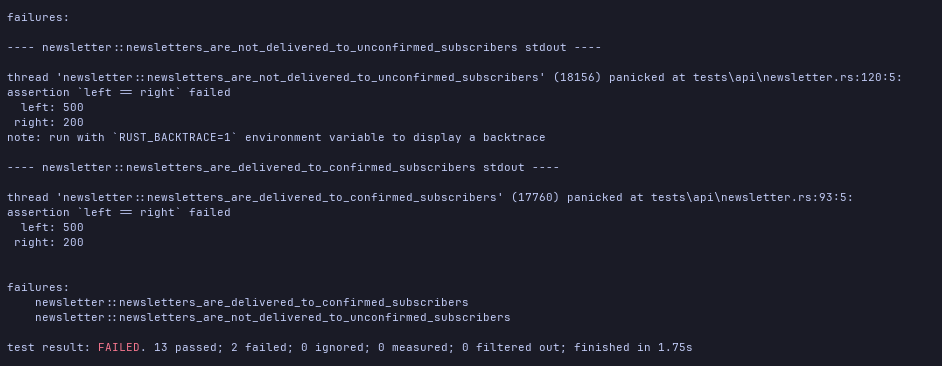

We run `RUST_LOGS=true cargo test --test  -- newsletters_are_not_delivered` to see the logs we see;

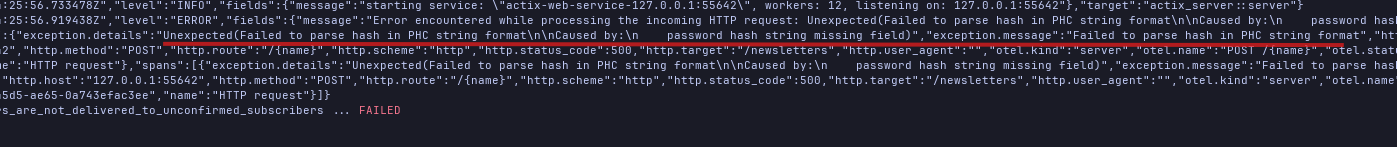

When we look at the password generation code of our `test_user` [here](#sha3) we see that we are still storing a `sha3` hash instead of `argon2` PHC string formatted hashes.  
Lets fix this.

```Rust
//! test/api/newsletter.rs
// [...]
use argon2::{Argon2, PasswordHasher, password_hash::{SaltString, rand_core::OsRng}};

// [...]

impl  TestUser {
    // [...]
    async fn store(&self, db_pool: PgPool) {
        let salt = SaltString::generate(&mut OsRng);
        let password_hash = Argon2::default()
            .hash_password(
                self.password.expose_secret().as_bytes()
                &salt
            )
            .expect("Failed to hash password")
            .to_string();

        sqlx::query!(
            r#"
                INSERT INTO users (user_id, username, password_hash)
                VALUES ($1, $2, $3)
            "#,
            self.user_id,
            self.username,
            password_hash
        )
        .execute(db_pool)
        .await
        .expect("Failed to perform query to create a test user");
    }
}
```
All the test suites should passnow.

### 10.02.4. Do Not Block The Async Executor

#### 10.02.4.1. Overview

##### 10.02.4.0.0 Skimming: What did you notice and why? Any Questions

_**What?**_  
- Blocking tasks, cooperative scheduling and async tasks.
- Lifetime error we get because of `Password::new(&expected_password_hash)`

_**Wny?**_  
- Seems like blocking tasks are asynchronous tasks that take too long to return a result and therefore are meant to yeild back control to the
  scheduler for other async tasks to make progress without being blocked. Tasks that could block are meant to be run in a separate threadpool
  `tokio::task::spawn_blocking` so that they don't interfere with other async tasks.

- The lifetime issue is somewhat unclear. Would be good to revisit.

_**Questions?**_  
None


##### 10.02.4.0.1. Deep Dive: Summarize, ELI5, Connect

_**Summary**_  
We primarily unpack how async works and how to handle blocking tasks like CPU intensive tasks.  
Here's a [link](https://claude.ai/share/44ed5331-1cb7-4acd-905d-cf1f4f4a5681) to a Claude conversation deep dive into async vs blocking tasks, threads & processes.

1. We first inspect the how long password verification takes.
2. Then understand the nature of blocking tasks
3. Add `spawn_blocking` block and call `Argon2.verify_password`
4. Extract out returning PHC string parsing and password verification into its own function.
5. Add `span_blocking_with_tracing` helper function to `telementry.rs` module, and use it on `validate_credentials`



**1. Inspecting how long password verification takes**

To do this we will do a bit of refactoring. 
- Add `.with_span_events(FmtSpan::Close)` in `src/telemetry.rs`
- We'll separate the query to its own function `get_stored_credentials`. W
- Compute time elapsed for password verification.

_Add _`with_span_events(FmtSpan::CLOSE`) to `fmt::layer` to`get_subscriber` in `src/telemery.rs`._
```Rust
//! src/telemetry.rs
// [...]

pub fn get_subscriber<Sink>(/**/) -> impl Subscriber + Send + Sync 
where 
    Sink: for <'a> MakeWriter<'a> + Send + Sync + 'static
{
    // [...]
    let formatting_layer = fmt::layer()
        .json()
        .with_writer(sink)
        .with_span_events(FmtSpan::CLOSE)
        .with_current_span(true);

    // [...]
}
```

_Compute time elapsed for password verification_ +  

```Rust
//! src/routes/newsletter.rs
// [...]

#[tracing_instrument(name="Validate Credentials", skip(db_pool, credentaisl))]
async fn validate_credentails(db_pool: &PgPool, credentials: Credentials) -> Result<Uuid, PublishError> {
    let (user_id, expected_password_hash) = get_stored_credentials(db_pool, username)
        .await
        .map_err(PublishError::Unexpected)?
        .ok_or_else(|| PublishError::Auth(anyhow::anyhow!("Invalid Username".)))?;
    
    let start_time = std::time::Instant::now();
    let outcome = Argon2::default().verify_password(
        credentials.password_hash.expose_secret().as_bytes(),
        &expected_password_hash
    );
    tracing::info!(elapsed_milliseconds = start_time.elapsed().milliseconds, "Verifed password hash.");
    outcome
    .context("Invalid Password")
    .map_err(PublishError::Auth)?;

    Ok(user_id)
}

#[tracing::instrument(name="Get Stored Credentials", skip=(db_pool, username))]
async fn get_stored_credentials(db_pool: &PgPool, username: &str) -> Result<Option<(user_id, SecretString)> anyhow::Error>{
    let row = sqlx::query!(
        r#"
            SELECT user_id, password_hash
                FROM users
            WHERE username = $1;
        "#
        username
    )
    .fetch_optonal(db_pool)
    .await
    .context("Failed to perform query to retreive stored credentials.")?
    .map(|r| (r.user_id, r.password_hash));

    Ok(row)
} 
```

We can inspect the logs by running the command;  
``` bash
TEST_LOG=true cargo test --quiet --release newsletters_are_delivered | grep "Verified password hash" | jq -R "fromjson"
```
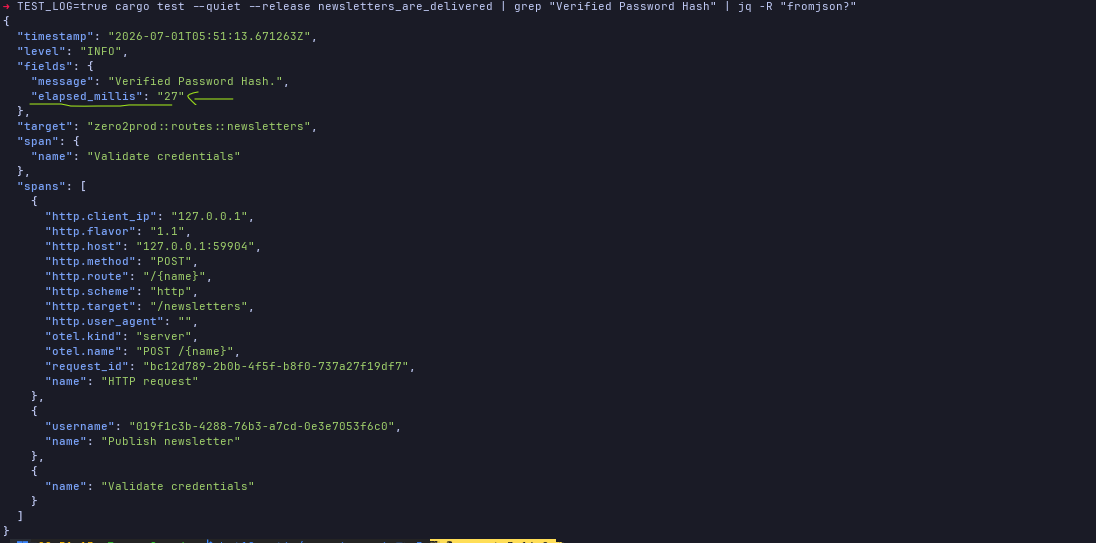

We can see that it took about 27 milliseconds. This is very likely to cause issues under load causing the infamous **blocking problem**.  
> **Note**: In the book the elapsed time is ~ 10ms. Our is significantly higher at almost 3 times the time elapsed.  
> Maybe we can attribute this to the `19MiB` memory cost for our default compared to the original `15MiB` memory cost for Argon2.

###### Learning-1: Making Spans Emit A Close Event

By adding `.with_span_event(FmtSpan::Close)` in the `fmt` in the `telemetery.rs` module, we make spans emit a close event systematically whenever we build the JSON fmt layer in `get_subscriber`.  
This allows us to configure how synthesized events are emitted at points in a `spans` lifecycle. `FmtSpan::CLOSE` events will be synthesized when a span closes, and the event field will contain  
`busy time` (total time for which a span was entered) and `idle time` (time for which the span existed but was not entered)
Might proceed with this approach because of the next section on _User Enumeration_ when tracking the time it takes for a non existent user login vs existing user login.

More on that [here](https://claude.ai/share/05b6d6c9-d3be-4df7-89fb-7865fbd6a5e5) from a conversation with Claude.

###### Learning-2: Formating tracing output in pretty json

Below is an example where we want to a json log output with the key word _"Verified"_ for a speciific test that has the substring   
`newsletters_are_delivered`
```bash
TEST_LOG=true cargo test --quiet --release newsletters_are_delivered 2>&1 | grep "Verified" | jq -R 'fromjson?'
```

This produces the following output
```bash
➜ TEST_LOG=true cargo test --quiet --release newsletters_are_delivered 2>&1 | grep "Verified" | jq -R 'fromjson?'
{
  "timestamp": "2026-06-26T11:00:46.398758Z",
  "level": "INFO",
  "fields": {
    "message": "Verified password hash",
    "elapsed_ms": "27"
  },
  "target": "zero2prod::routes::newsletters",
  "span": {
    "name": "Validate credentials"
  },
  "spans": [
    {
      "http.client_ip": "127.0.0.1",
      "http.flavor": "1.1",
      "http.host": "127.0.0.1:51900",
      "http.method": "POST",
      "http.route": "/{name}",
      "http.scheme": "http",
      "http.target": "/newsletters",
      "http.user_agent": "",
      "otel.kind": "server",
      "otel.name": "POST /{name}",
      "request_id": "699bc4fd-f2b0-4ef7-990a-bec001ae0fd1",
      "name": "HTTP request"
    },
    {
      "username": "019f0396-dc48-7451-b562-c3d60c4669a1",
      "name": "Publish newsletter"
    },
    {
      "name": "Validate credentials"
    }
  ]
}
```

**Note:** The order of the `grep` command matters. 
Running the command below;
```bash
TEST_LOG=true cargo test --quiet --release newsletters_are_delivered 2>&1 | jq -R 'fromjson?' | grep "Verified" 
```
results in;
```bash
➜ TEST_LOG=true cargo test --quiet --release newsletters_are_delivered 2>&1 | jq -R 'fromjson?' | grep "Verified"
    "message": "Verified password hash",
```

Conversation with [Claude](https://claude.ai/share/8b6bf501-9a1d-4cad-b524-fbab4499b617) where I learn about adding the `jq .` to add json formating to tracing outputs.

##### Blocking problem and Cooperative Scheduling

Rough shape of this section.

Rust `async`/`await` is built around a concept known as **cooperative scheduling**.
Let imagine a simple example `my_fn` 
```Rust
async fn my_fn() {
    a().await;
    b().await;
    c().await;
}
```

`my_fn` returns a `Future`. When a `Future` is awaited `tokio` our async runtime enters into the picture and begins to poll the returned `Future`.  
Assuming that the inner function within `my_fn` don't have nested await calls within themselves, polling `my_fn`'s `Future` can be represented by 
tracking the state of the `Future` represented by the enum below.  
```Rust
enum MyFnFuture {
    Initialized,
    CallingA,
    CallingB,
    CallingC,
    Complete,
}
```
We have different states in `MyFnFuture` for each `.await` in our `async` function body.  
Each `.await` call returns either a `Ready` or `Pending` state and then **yields** control back to the executor. That is why `.await` calls are often named **yield points**.

The executor can then choose to poll the same future again and progress to the next `.await` if a task is complete, or to prioritize making progress on another tasks.   
This is how async runtimes like `tokio` make progress **concurrently** on multiple tasks $\textemdash$ by continously parking and resuming each of them.

The underlying assumption is that most _async_ tasks are performing some kind I/O work $\textemdash$ most of their execution time is spent waiting on soemthing else to happen (.e.g  
the OS notifying us that a file is ready to be read on a socket.) Therefore we can _effectively_ perform many more tasks concurrently than we would achieve by a dedicated parallel  
unit of execution.

This model works great assuming that tasks **cooperate** and yeild back control to the executor quickly and frequently ideally less than 10 - 100 microseconds ($\micro$s). If the async tasks  
take longer or even worse never yeild back control, the executor cannot make progress on other tasks. This is what we call the blocking problem where a task is blocking the executor/  
async thread.

CPU heavy workloads are the common culprit for blocking tasks, because they do not yeild back control to the executor until they are complete, that are likely to take longer than 1ms to complete.  
A good example is our password verification with `argon` which we specifically choose because it is **computationally demanding**.

To play nicely with tokio we offload CPU intensive work to a separate dedicated thread pool for blocking tasks using `tokio::task::spawn_blocking`. This ensures that we do not interfere with  
scheduled async tasks.

This table is just FYI.


| Prefix | Symbol | Fraction of a Second | Scientific Notation | Numeric Value |
| :--- | :--- | :--- | :--- | :--- |
| **Millisecond** | ms | One thousandth | 10⁻³ s | 0.001 seconds |
| **Microsecond** | μs | One millionth | 10⁻⁶ s | 0.000001 seconds |
| **Nanosecond** | ns | One billionth | 10⁻⁹ s | 0.000000001 seconds |
| **Picosecond** | ps | One trillionth | 10⁻¹² s | 0.000000000001 seconds |


Alright. Lets offload password verification to an blocking threadpool.
```Rust
//! src/routes/newsletter.rs
// [...]

#[tracing::instrument(/**/)]
async fn validate_credentials(/**/) ->  Result<Uuid, PublishError> {
    // [...]
    tokio::task::spawn_blocking(move || {
        Argon2::default()
            .verify_password(
                credentials.password_hash.expose_secret().as_bytes(),
                &expected_password_phc_format
            )
    })
    .await
    .context("Failed to spawn blocking task thread")
    .map_err(PublishError::Unexpected)?
    .context("Invalid Password")
    .map_err(PublishError::Auth)?;
}
```
Unfortunately this does not compile leading to the error below.

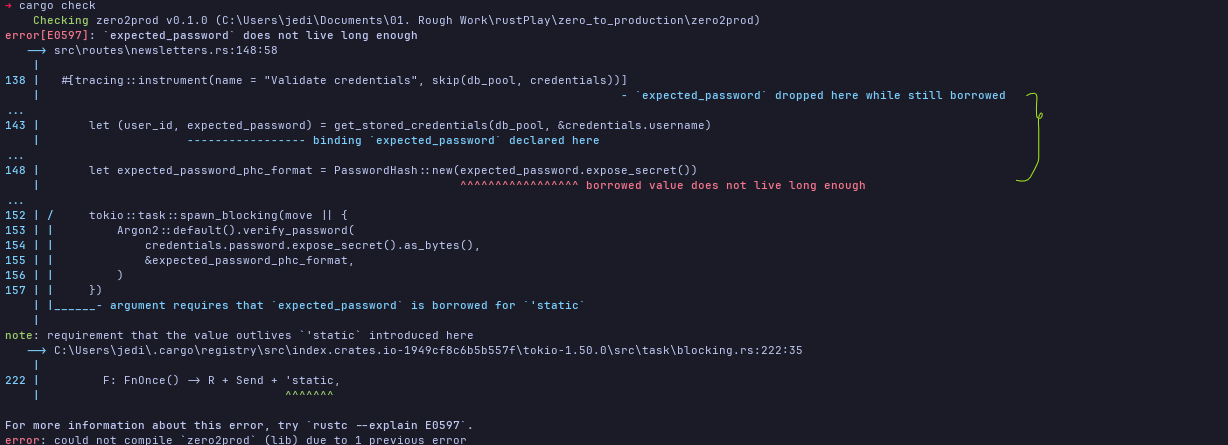

The error informs us that `expected_password` does not live long enough when it is used by `PasswordHash` to generate our PHC string formated hash.  
`PasswordHash` holds a reference to the string it was parsed from, meaning that we would have to guarantee that the reference lives long enough when we used the resultant  
formatted hash in our closure in the blockin task.

To work around this lets wrap both the PHC string format parsing and hash verfication in a separate function that we can then call in the `spawn_blocking`.
```Rust
//! src/routes/newsletter.s
// [...]

// [...]

#[tracing::instrument(/**/)]
async fn validate_credentials(/**/) -> Result<Uuid, PublishError> {
    // [...]

    tokio::task::spawn_blockin(move || {
        verify_password_hash(expected_password, credentials.password)
    })
    .context("Failed to spawn blocking task thread.")
    .map_err(PublishError::Unexpected)??;

    // [...]
}

// [...]

#[tracing::instrument(name="Verify Password Hash", skip(expected_password, password_candidate))]
async fn verify_password_hash(
    expected_password: SecretString,
    password_candidate: SecretString,
) -> Result<(), PublishError> {
    let expected_password_phc_format = PasswordHash::new(expected_password.expose_secret())
        .context("Failed to parse hash in PHC string format.")
        .map_err(PublishError::Unexpected)?;

    Argon2::default()
        .verify_password(
            password_candidate.expose_secret().as_bytes(),
            &expected_password_phc_format,
        )
        .context("Invalid Password.")
        .map_err(PublishError::Auth)
}
```

This should compile.

#### 10.02.4.1. Tracing Context Is Thread-Local

##### 10.02.4.1.0 Skimming: What did you notice and why? Any Questions

_**What?**_
- Attaching current span to newly spanwed thread.

_**Why?**_
- We write a custom function in order to do this utilizing `JoinHandle`, `FnOnce`, and trait bound definitions. A nice pattern to learn from.

_**Questions?**_  
None



##### 10.02.4.1.1. Deep Dive: Summarize, ELI5, Connect

_**Summary**_  

Because `verify_password_hash` is being called in a separate thread (via `tokio::task::spawn_blocking`), it does not inherit the tracing properties from its parent span corresponding to the request, e.g `request_id`, `http.method`, `http.target` e.t.c. as shown below.

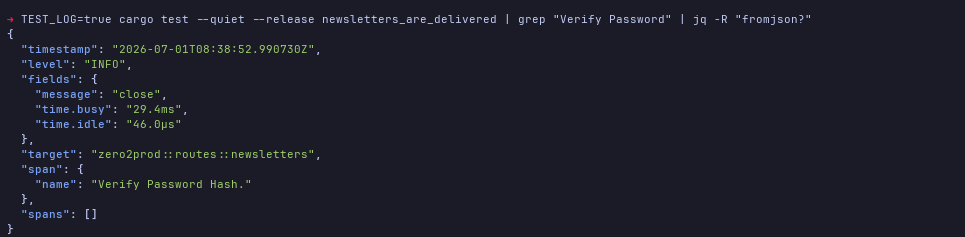

Looking at `tracing`'s docs, we know
<div style="background-color: #313B51; color: white; padding: 15px; border-radius: 15px; border: 1px solid white;">

<a href ="https://docs.rs/tracing/latest/tracing/span/index.html#span-relationships">Spans</a> form a tree structure $\textemdash$ unless it is a  
root span, all spans have a _parent_, and may have one or more _children_. When a new is span is created, the **current span** becomes the new  
span's parent.

</div>
</br>

The current span is the one returned by `tracing::Span::current` $\textemdash$ let's check its [documentation](https://docs.rs/tracing/latest/tracing/struct.Span.html#method.current)

<div style="background-color: #313B51; color: white; padding: 15px; border-radius: 15px; border: 1px solid white;">

Returns a handle ot the span <a href="https://docs.rs/tracing/latest/tracing/trait.Subscriber.html#method.current_span">considered by the `Subscriber`</a> to be the current span.

If the _subscriber_ indicates that it does not track the current span, or that **the thread from which this function is called is not currently  
inside a span**, the returned span will be disabled.

</div>

**current span** actually means "active span for the current thread", and this is the reason why we aren't inheriting any properties from parent thread because we are spawning a new thread dedicated to running blocking task and then calling `verify_password_hash`.

By explicitly attaching the current span to the newly spawned thread, we work around the issue

```Rust
//! src/routes/newsletter.rs
// [...]

// [...]

#[tracing::instrument(/**/)]
async fn validate_credentials(/**/) -> Result<Uuid, PublishError> {
    // [...]
    // This executes before spawning the new thread
    let current_span = tracing::Span::current();
    tokio::task::spawn_blocking(move || {
        // We then pass ownership to it into the closure and explicitly executes all our computation
        // within its scope
        current_span::in_scope(|| verify_password_hash(expected_password, credentials.password));
    })
    .context("Invalid Password")
    .map_err(PublishError::Auth)?;
    // [...]
}
```

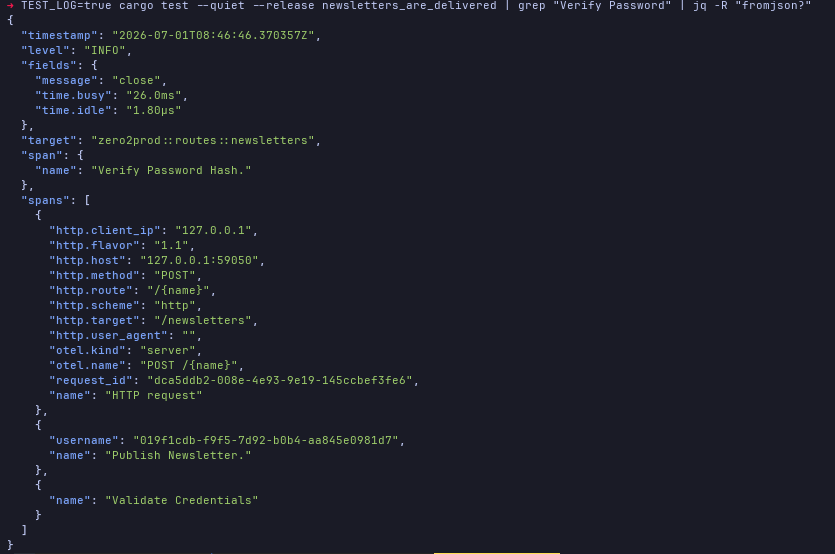

Because we might want to reuse this functionality $\textemdash$ attaching current span to a blocking task thread, let's add a helper function to  
`src/telementry.rs` for this.
```Rust
//! src/telementry
// [...]
use tokio::task::JoinHandler;

fn spawn_blocking_with_tracing<F, R>(f: F) -> JoinHandler<R>
where
    F: FnOnce() -> R + Send + 'static,
    R: Send + 'statix
{
    let current_span = tracing::Span::current();
    tokio::task::spawn_blocking(move || current_span.in_scope(f)) 
}
```

We then call it the helper function in `src/routes/newsletter.rs` as follows.
```Rust
// src/routes/newsletter.rs
// [...]
use crate::telemetry::spawn_blocking_with_tracing;

#[tracing::instrument(/**/)]
async fn validate_credentials(/**/) -> Result<Uuid, PublishError> {
    // [...]
    spawn_blocking_with_tracing(move || 
        verify_password_hash(expected_password, credentials.password)
    )
    .await
    .context("Invalid Password")
    .map_err(PublishError::Auth)??;
}
```

We can now easily reach for the helper every time we need to offload some CPU-intensive computation to a dedicated threadpool.

### 10.02.5. User Enumeration

##### 10.02.5.0. Skimming: What did you notice and why? Any Questions

_**What?**_
- Timing attacks.
- Realizing that Invalid username and/or password is a good generic way of rejecting both non-existent accounts or password-username mismatch.
  Addressing timing attacks makes it difficult to differentiate between invalid credentials and non-existent credentials.

_**Why?**_
- A clever tactic to identify valid users of an application vs non-existent in Saas applications with specific registered domains as login credentials ( e.g. user@somesaas.com)
-  Imagining a scenario where we know a valid username/email because of timing attacks and initiate a password reset to gain control of the account.

_**Questions?**_  
None



##### 10.02.4.1.1. Deep Dive: Summarize, ELI5, Connect

_**Summary**_  
Here we primarily address a _**timing attack**_ where an attacker is able to infer an existing user by checking how long it takes to verify existing vs non-existent users.  
For identifying if a we have valid gmail credentials, this might not be helpful, as there are many other ways to identify valid gmail address. For SaaS application   
a _timing attack_ can help us identify legitimate email credentials that can then be used for other attacks such as phishing as a start.

_timing attacks_ are part of a broader class of _**side-channel**_ attacks, and the ability to confirm if a given user exist or not, we are looking at a potential  
**User Enumeration Vulnerability**.

To be able to expose this vulnerability we write 2 tests
1. `non_existent_users_are_rejected()`
2. `invalid_passwords_are_rejected()`

Then we proceed to add default/placeholder password hash that eliminates timing attacks by ensuring that both non existing credentials and invalid credentials take the  
amount of time to verify.

Lets add the first test
```Rust
//! tests/api/newsletter.rs
// [...]

#[tokio::test]
async fn non_existent_user_is_rejected() {
    // Arrange
    let app = spawn_app().await;
    let placeholder_credentials = Uuid::now_v7().to_string();

    // Act
    let response = reqwest::Client::new()
        .post(format!("{}/newsletters", &app.address))
        .basic_auth(&placeholder_credentials, Some(&placeholder_credentials))
        .json(&serder_json::json!({
            "title": "Newsletter title",
            "content": {
                "plain": "Newsletter as plain text",
                "html": "<p>Newsletter as plain text</p>",
            }
        }))
        .send()
        .await
        .expect("Failed to execute post newsletter request");

    // Assert
    assert_eq!(401, response.status().as_u16());
    assert_eq!(r#"Basic realm="publish""#, response.headers()["WWW-Authenticate"])
}
```

The test should pass. We run the command below to inspect the test logs for how long the validation request takes.
```bash
TEST_LOG=true cargo test --quiet --release non_existent_user_is_rejected | grep "Validate Credentials" | jq -R "fromjson?"
```

We get the below output.

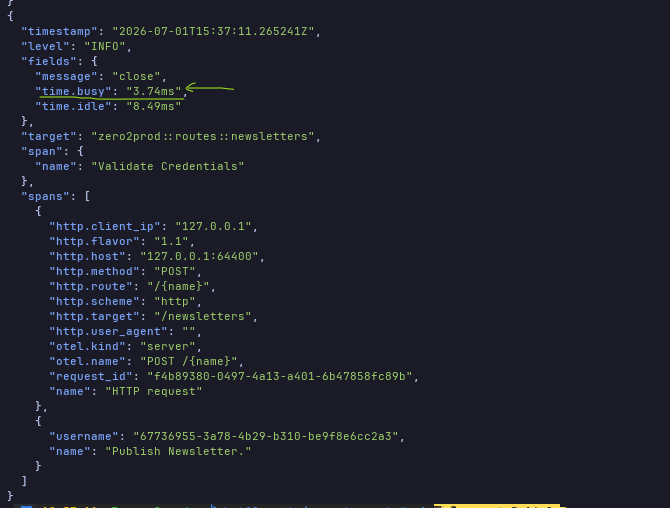

The `"time.busy"` is what we are mainly interested in because that is the amount of time spent verifying the credentials, which in this case is about 3.74 milliseconds.

We add the second test `invalid_password_is_rejected`, and inspect the test logs to see how long that takes as well.
```Rust
#[tokio::test]
async fn invalid_password_is_rejected() {
    // Act
    let app = spawn_app().await;
    let username = app.test_user.username;
    let invalid_password = Uuid::now_v7().to_string();
    
    // Arrange
    let response = reqwest::Client::new()
        .post(format!("{}/newsletters", &app.address))
        .basic_auth(username, Some(&invalid_password))
        .json(&serde_json::json!({
            "title": "Newsletter title",
            "content": {
                "plain": "Newsletter as plain text.",
                "html": "<p>Newsletter as plain text.</p>",
            }
        }))
        .send()
        .await
        .expect("Failed to execute newsletter post request in test.");
    
    // Assert
    assert_eq!(401, response.status().as_u16());
    assert_eq!(r#"Basic realm="publish""#, response.headers()["WWW-Authenticate"]);
}
```

When we run the below command on the terminal this time
```bash
TEST_LOGS=true cargo test --quiet --release invalid_password_is_rejected | grep "Validate Credentials" | jq -R "fromjson?"
```
We get;

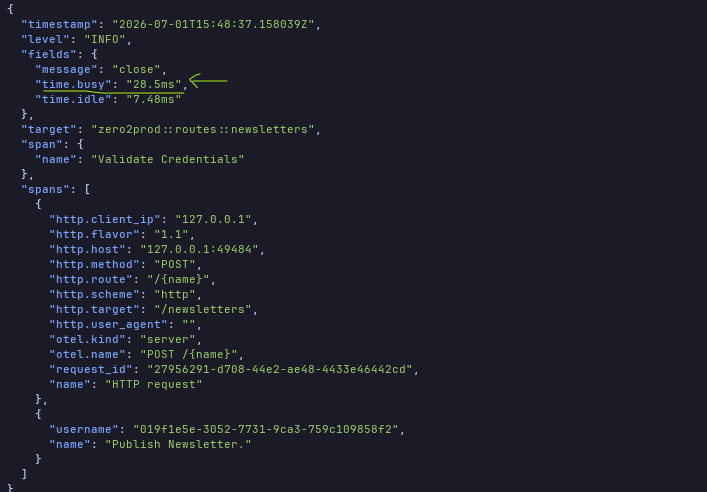

The `"time.busy"` is about $10x$ more than the previous test at `28.5` milliseconds, meaning validating invalid credentials is about 10 times slower. What is the best way to address this potential _user enumeration vulnerablity_.
1. Eliminate the time difference between validating non existent credentials and existing ones.
2. Limit number of failed authentication attempts.

While the 2nd option makes generally valuable for a robust protection against brute-force attempts, it requires as keeping track of some state. Let's pause on that for  
now.

The first option is a bit straight forward. Our `validate_credentials` recipe is currently
- Fetch `user_id` and `expected_password` queried by `username`
- If the `username` does not exist we return a `401`
- If they exist we go ahead and verify the stored `expected_password` vs the credentials `password` the user provided on authentication.

This means we are doing an early exist if we don't retrieved stored credentials. We can eliminate this early exit by providing a placeholder PHC string formatted  
password hash and set `user_id` initially to `None`. We then update the values to the actual stored user id and password if the `username` exist, otherwise we use our
placeholder password hash for the verification step. 

This ensures the computationally demanding step of verifying the password will be executed regardless of valid or invalid password.

Lets do this.
```Rust
//! src/routes/newsletter.rs
// [...]

#[tracing::instrument(/**/)]
async fn validate_credentials(/**/) -> Result<Uuid, PublishError> {
    let mut user_id = None;
    let mut expected_password = SecretString::from(
      "$argon2id$v=19$m=19000,t=2,p=1$OqVpaPog6F9sxlWW5VoHkA$4uDo1cl2daKq1ZgmmvtQBfG3wwmI8Nk4i8gHk6pwrYA".to_string()      
    );

    if let Some((stored_user_id, stored_password_hash)) = get_stored_credentials(db_pool, &credentials.username)
        .await
        .map_err(PublishError::Unexpected)?
    {
        user_id = Some(stored_user_id);
        expected_password = stored_password_hash
    };

    spawn_blocking_with_tracing(|| { verify_password_hash( expected_password, &credentials.password) });

    user_id.ok_or_else(|| PublishError::Auth(anyhow::anyhow!("Invalid Username")))
}
```

Now there should be no statistical difference in validation time between existing and non existent credentials

Below is a test log excerpt from the `invalid_password_is_rejected` test.

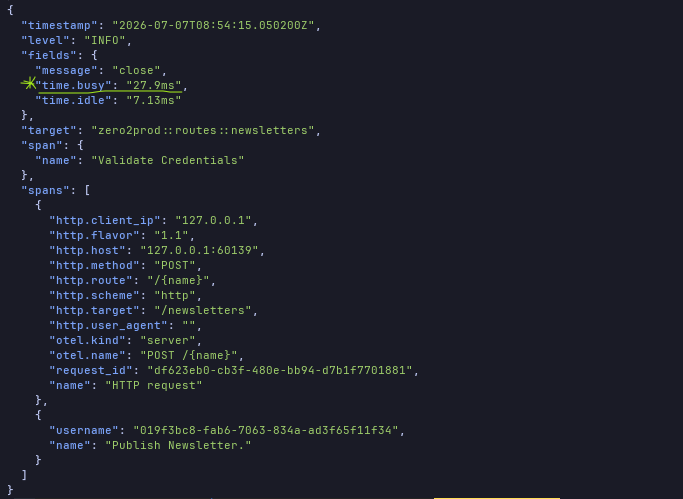

And below an excerpt from the `non_existent_user_is_rejected` test.

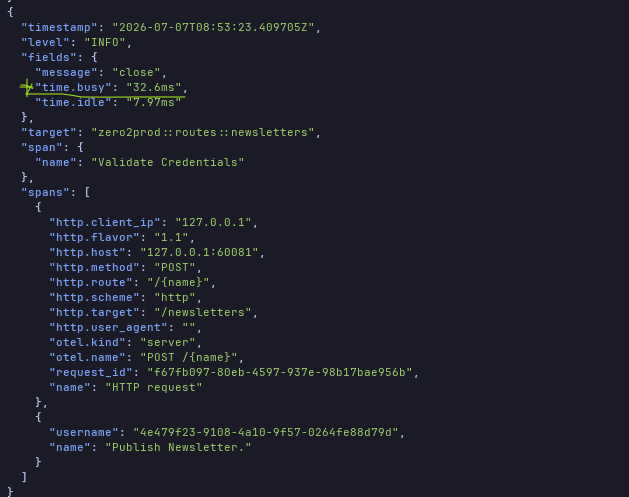

## 10.03. Is It Safe?

##### 10.03.0.0. Skimming: What did you notice and why? Any Questions

_**What?**_  
- Client Credentials via OAuth2
- Session based authenticaiton
- Identity federation that relies on OpenID connect, an identity layer on top of OAuth2 standard.


_**Why?**_  
- Core concepts in Authentication/Authorization and security.
- 

_**Questions?**_  
- Would a detour to understanding how the OAuth2 standard works be worth it?

##### 10.03.0.0.1. Deep Dive: Summarize, ELI5, Connect

_**Summary**_  

When thinking about how secure/safe our basic password-based authentication is, we consider 3 key verticals
- **Transport Layer Security (TLS)** - Currently when using the Basic Authentication Scheme communication between the client and server when passing credentials is encoded
  not encrypted. Using HTTPS ensures that no one can eavesdrop the traffic the client and server and thus be able to decode and compromise the credentials
- **Password Reset** - Incase stored credentials are compromised we need to provision a way for users to reset their password.
- **Interaction Types** - Depending on which interaction types we allow for our backend service/api we need to ensure that appropriate security measures are applied. The common
  interaction types we have to consider are
   - _**Machine to Machine**_ - Our backend service is consumed by another API. We have to be able to authenticate & authorizes requests from such APIs
   - _**Person through a browser interaction**_ - This is the typical client, server interaction whereby a user has some front end interface that exposes our backend service
     functionality. We have to ensure that only valid credentialed users have access to priviledged functionality
   - _**Another API on behalf of person**_ - Primarily for automations that a user wants to enable based on our backend functionality. Imagine another service that a user want to
     use to automate reviewing a published newsletter, that needs to be **scoped** to only review and nothing else. This is different from the first scenario of Machine to Machine
     via API interaction.

How safe is our current implementation for each of the above situations/scenarios?

### 10.03.1. Transport Layer Security (TLS)

Our application is already being served over HTTPS, so we are covered here. There is chance of someone eaves dropping on our traffic and extracting credentials 

### 10.03.2. Password Reset.

We **DO NOT** have a way currently for a user to reset their password. This is something we'll need to add to our implementation

### 10.03.3. Interaction Types.

For interaction types, we boiled them down to
1. Machine To Machine (API)
2. Person Via a Browser
3. Machine to Machine on behalf of a person. (Scoped API)

Lets look at each one by one.

### 10.03.4. Machine To Machine.

#### 10.03.4.0. Overview

One way to do this is where the both services, the consuming and our backend service uses a mutual TLS

#### 10.03.4.1. Client Credentials via OAuth2

Using OAuth2 client credential flow, instead of username and password, we use _client ids_ and _client secrets_ that authenticates with an authorization server  
to generate a temporary Json Web Token (JWT) for example that our backend uses to authenticate/authorize requests. Our **API never sees the actual password**

JWT validation is not without its risk. [Here's](https://www.youtube.com/watch?v=NEqZaHQnqlk) a great resource on hacking JWTs.

### 10.03.5. Person Via Browser.

#### 10.03.5.0. Overview

With our current implementation a user would be required to authenticate on every request. Basically resubmit a username and password to authenticate every request they make  
from the browser. This makes for a very poor user experience. A popular way to handle this is for the server to hold some state around an already authenticated user   
that allows a sequence of request from the same browser without having to resubmit credentials. i.e. remember that this user is authenticated and therefore authorize  
preceding sequence of request from this browser. This is accomplished via **sessions**.

This is where the server generates a one-time short lived token on successful user authentication. The token is included as part of other requests. This token is referred to as  
as _**session token**_ usually store in the browser as a secure cookie. An autheticated session tokens are desgined be short-lived to reduce the likelihood that a valid session is  
compromised. A forceful log-out occurs on session token expiry, necessating a re-authentication, which is a better experience that having to reset a password.

This approach is often reffered to as **Session Based Authentication**.

#### 10.03.5.1. Federated Identity

Another alternative is delegating authentication to third party **identity providers** via Social logins like Google or Facebook Sign in. This makes it very  
convinient for our users to use credentials that they are already used to, making for a great user experience. 

Social auth relies on **identity federation** which in turn relies on **OpenID Connect (OIDC)** a comon impleemetation of an identity layer on-top of OAuth2.

### 10.03.6. Machine to machine, on behalf of a person.

Although this is different from the prior Machine to Machine interaction type because actions/permissions, are scoped, the authentication mechanism fit for this is OAuth2.  
A authentication token from a third party server generated via a client id and secret are used to authorize request to our backend. Our backend has no need for  
storing any credentials, just validating that requests are authorized.

## 10.04. Interlude: Next Steps.

##### 10.01.0.0. Skimming: What did you notice and why? Any Questions

_**What?**_  
- Converting our Basic Authentication to using a Login form with session based authentication

_**Why?**_  
- Looks fun

_**Questions?**_  
- Should we commit to askama now or at the end?
  Tempted to do askama now. But it makes sense to explore it later. Or maybe htmx might be a better exploration here.

##### 10.01.0.0.1. Deep Dive: Summarize, ELI5, Connect

Because a person interacting with our service via a browser is our primary target as of now, we will proceed with **Session Based Authentication** which we will build  
from scratch. This is include
- A login form
- A simple bare bones dashboard with
    - password reset form
    - logout.
    
It will give use an opportunity to tackle a few security challengs such as
- XSS
- new concepts such as HMAC tags
- new tooling i.e. flash messages, `actix-session`

## 10.05. Login Form.

### 10.05.1. Serving HTML Pages

##### 10.05.0.0. Skimming: What did you notice and why? Any Questions

_**What?**_  
- [Internet Is Hard](https://internetingishard.netlify.app/) - For indepth introduction to HTML and CSS
- [Common Rust Lifetimes Misconceptions](https://github.com/pretzelhammer/rust-blog/blob/master/posts/common-rust-lifetime-misconceptions.md#common-rust-lifetime-misconceptions) -
  For a good deep dive into Rust Lifetimes
- [Chrome Dev Tools](https://developer.chrome.com/docs/devtools/open/) & [Firefox Dev Tools](https://firefox-source-docs.mozilla.org/devtools-user/index.html) Documentation

_**Why?**_  
- This book has a treasure trove of cool additional material around Rust, web and software engineering in general.
- All the resources are from the footnotes.

_**Questions?**_  
None


##### 10.05.0.0.1. Deep Dive: Summarize, ELI5, Connect

_**Summary**_  

We primarily serve our first well-formed web page by
1. Adding a `home` module with `mod.rs` and `home.html` to `src/routes`. And do the approrpriate module loading.
2. Add simple html to our `home.html`
3. Wire up the html to be served via a `home` handler in `mod.rs` and update the handler to return a html body content type.
4. Update `startup.rs`'s `run` function with the route handler for handler for the `/home` route

```HTML
<!--src/routes/home/home.html-->
<!DOCTYPE html>
<html lang="en">
  <head>
    <meta http-equiv="conten-type" content-type="text/html" charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Newsletter Home</title>
    <link rel="icon" href="data:,">
  </head>
  <body>
    <p>Welcome to our Newsletter.</p>
  </body>
</html>
```

```Rust
//! src/routes/mod.rs
// [...]
mod home;

// [...]
pub use home::*;
```
```Rust
// src/routes/home/mod.rs
use actix_web::{HttpResponse, http::header::ContentType};

pub async fn home() -> HttpResponse {
    HttpResponse::Ok()
        .content_type(ContentType::html())
        .body(include_str!("home.html"))
}
```
```Rust
//! src/startup.rs
//[...]
use crate::routes::{ /**/,  home }

// [...]

fn run(/**/) -> Result<Server, std::io::Error> {
    // [...]
    let server = HttpServer::new( move || {
        App::new()
            // [...]
            .route("/home", web::get().to(home))
            // [...]
    });

    // [...]
}
```